Question 1:
 
A retail store wants to identify customers who make frequent purchases. Given the dataset below, write a code to:
1.Group customers by their IDs.
2.Calculate the total number of purchases per customer.
3.Identify the top 3 frequent customers.


In [ ]:
import pandas as pd

data = {'Customer_ID': [101, 102, 103, 101, 104, 102, 101, 105, 102, 103],
        'Purchase_Amount': [200, 150, 180, 220, 300, 200, 100, 400, 250, 300]}
data = pd.DataFrame(data)
data

tot_purchases = data.groupby('Customer_ID').sum().reset_index()

print('Total Purchases per Customer:')
print(tot_purchases)

top_customers = tot_purchases.sort_values(by='Purchase_Amount', ascending=False).head(3)

print('\nTop 3 Frequent Customers:')
print(top_customers)


Total Purchases per Customer:
   Customer_ID  Purchase_Amount
0          101              520
1          102              600
2          103              480
3          104              300
4          105              400

Top 3 Frequent Customers:
   Customer_ID  Purchase_Amount
1          102              600
0          101              520
2          103              480


Question 2:

A company tracks the daily sales of a product over a month. You are tasked with identifying any abnormal sales data using the IQR (Interquartile Range) method.

In [60]:
import numpy as np

data = {'Day': range(1, 31),
        'Sales': [25, 30, 28, 45, 55, 60, 22, 80, 95, 120,
                  33, 29, 27, 35, 40, 50, 85, 110, 105, 92,
                  30, 34, 31, 33, 36, 42, 44, 48, 90, 200]}
data = pd.DataFrame(data)

# Tasks:
# 1. Calculate the Q1 (25th percentile) and Q3 (75th percentile).
Q1=np.percentile(data['Sales'], 25)
Q3=np.percentile(data['Sales'], 75)

# 2. Determine the IQR.
IQR = Q3-Q1

print('Q1:', Q1, 'Q3:', Q3, 'IQR:', IQR)

# 3. Identify the Lower Bound and Upper Bound.
Lower = Q1 - IQR*1.5
Upper = Q3 + IQR*1.5
print('Lower Bound:', Lower, 'Upper Bound:', Upper)


# 4. Detect and display the outliers.

outliers = data[(data['Sales'] < Lower) | (data['Sales'] > Upper)]

print('Outliers Detected:')
print(outliers)

# 5. Replace the Outliers with the Median Value.
median_value = int(data['Sales'].median())

data.loc[outliers.index, 'Sales'] = median_value

print('Data After Replacing Outliers with Median:')
print(data)



Q1: 31.5 Q3: 83.75 IQR: 52.25
Lower Bound: -46.875 Upper Bound: 162.125
Outliers Detected:
    Day  Sales
29   30    200
Data After Replacing Outliers with Median:
    Day  Sales
0     1     25
1     2     30
2     3     28
3     4     45
4     5     55
5     6     60
6     7     22
7     8     80
8     9     95
9    10    120
10   11     33
11   12     29
12   13     27
13   14     35
14   15     40
15   16     50
16   17     85
17   18    110
18   19    105
19   20     92
20   21     30
21   22     34
22   23     31
23   24     33
24   25     36
25   26     42
26   27     44
27   28     48
28   29     90
29   30     43


Question 3:
 
A pharmaceutical company is testing the effectiveness of a new drug to reduce blood pressure. Two groups of patients were selected:

Group 1 (Treatment): Received the drug

Group 2 (Control): Received a placebo

The company wants to check if there is a significant difference in the blood pressure levels between the two groups using an Independent T-Test.

In [8]:
import pandas as pd
from scipy.stats import ttest_ind


data = {'Group': ['Treatment']*10 + ['Control']*10,
        'Blood_Pressure': [120, 115, 118, 123, 122, 119, 124, 117, 116, 121,
                            130, 135, 140, 138, 142, 136, 139, 134, 137, 141]}

data = pd.DataFrame(data)

# Group 1 (Treatment): Received the drug
# Group 2 (Control): Received a placebo

group1 = data[data['Group']=='Treatment']['Blood_Pressure']
group2 = data[data['Group']=='Control']['Blood_Pressure']

test = ttest_ind(group1, group2)

# Null Hypothesis : The drug has no significant effect, because there is no significant difference in the blood pressure levels between the two groups
# Alternative Hypothesis : The drug has a significant effect, because there is a significant difference in the blood pressure levels between the two groups

print('T-Statistic:', test[0])
print('P-Value:', test[1])


if test[1] < 0.05:
    print('Reject the Null Hypothesis: The drug has a significant effect.')
else:
    print('Fail to Reject the Null Hypothesis: The drug has no significant effect.')


T-Statistic: -11.870553692962726
P-Value: 6.008066605173374e-10
Reject the Null Hypothesis: The drug has a significant effect.


Question 4:

GlobalMart is a large retailer conducting advertisement campaigns in different regions. The company spends money on two types of advertisements: TV Ads and Social Media Ads

They want to analyze how these ads influence their sales.
Your task is to calculate the Covariance and Correlation to determine which type of ad has a stronger impact on sales.

In [31]:
# Tasks :
# 1.Calculate the Covariance between ad budgets and sales to measure the direction of the relationship.
# 2.Calculate the Correlation to measure the strength of the relationship.
# 3.Determine which type of ad is more effective for increasing sales.

data = {'Region': ['North', 'South', 'East', 'West', 'Central'],
        'TV_Ad_Budget':[200,300,400,500,600],
        'Social_Media_Budget': [150,250,300,450,500],
        'Sales':[20,35,50,60,80]}

data = pd.DataFrame(data)

covariance = data[['TV_Ad_Budget', 'Social_Media_Budget', 'Sales']].cov()

print( 'Covariance (TV Vs Sales):', covariance['TV_Ad_Budget']['Sales'])
print( 'Covariance (Social Media vs Sales):', covariance['Social_Media_Budget']['Sales'])

correlation = data[['TV_Ad_Budget', 'Social_Media_Budget', 'Sales']].corr()

print( 'Correlation (TV Vs Sales):', correlation['TV_Ad_Budget']['Sales'])
print( 'Correlation (Social Media vs Sales):', correlation['Social_Media_Budget']['Sales'])

print('TV Ads have a stronger impact on Sales.')


Covariance (TV Vs Sales): 3625.0
Covariance (Social Media vs Sales): 3225.0
Correlation (TV Vs Sales): 0.9958640886279954
Correlation (Social Media vs Sales): 0.9724846021568382
TV Ads have a stronger impact on Sales.


Question 5:

A company tracks the delivery time (in minutes) for its online orders. You are given the delivery times for 50 orders.

1. Calculate the mean and standard deviation of the delivery times.
2. Plot the Probability Density Function (PDF) to visualize the distribution.

Mean Delivery Time: 65.0625
Standard Deviation of Delivery Time: 41.718504212759115


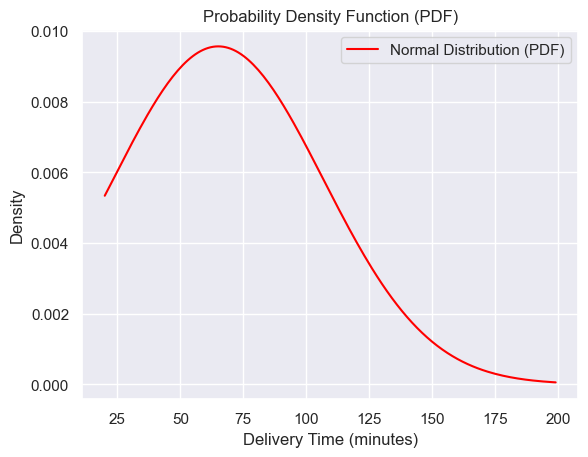

In [108]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pylab as plt

# Dataset (Delivery Times in Minutes):
 
data = [25, 30, 28, 45, 55, 60, 22, 80, 95, 120, 33, 29, 27, 35, 40, 50, 85, 110, 105, 92, 30, 34, 31, 33, 36, 42, 44, 48, 90, 200, 20, 25, 27, 32, 38, 41, 47, 58, 62, 77, 80, 84, 90, 110, 123, 145, 150, 160]

data = pd.DataFrame(data, columns=['Delivery Time'])
data_mean = data['Delivery Time'].mean()
data_std = np.std(data['Delivery Time'])

print('Mean Delivery Time:', data_mean)
print('Standard Deviation of Delivery Time:', data_std)

# Generate normal distribution curve
x = np.arange(data['Delivery Time'].min(), data['Delivery Time'].max(), 1)  
pdf = norm.pdf(x, data_mean, data_std)

# Plot PDF curve
plt.plot(x, pdf, color='red', label='Normal Distribution (PDF)')
plt.title('Probability Density Function (PDF)')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Density')
plt.legend()
plt.show()



   